In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from src.model import FiLMResNet2In, flatten_last
from src.normalizer import RunningMeanStd
from src.envpacker import packenv, packenv_batch
from src.utils import transition_ability_batched, update_v_history
import torch
from torch import nn
import torch.nn.functional as F
from tqdm import tqdm
import wandb
import os

## 1. Configs

In [ ]:
# Training configs
AGENTS = 50     # number of agents
LEARNING_RATE = 1e-3
TRAINING_STEPS = 30000
BATCH_SIZE = 10
DISPLAY_STEP = 100 # For visualization
TRAIN_STEP_INTERVAL = 2 # Interval of steps between training episodes
LAMBDA_AUX = 1.0 # Loss weighting parameters
LAMBDA_FOC = 1.0
MAX_HISTORY_LEN = 50


# Bewley model parameters
theta = 1 # CRRA
beta = 0.975 # Discount factor
A = 1 # Technology parameter
alpha = 0.33 # Capital share of income
gamma = 2 # Inverse Frisch elasticity
########################################### (MiLF inputs)
r = 0.04 # Interest rate (Return to savings)
w = 1 # Wage rate (Return to labor)
delta = 0.06 # Depreciation rate of capital
TAX_PARAMS = {
    "tax_consumption": 0.065,          # Consumption tax (fixed)
    "tax_income": 0.2,                # Tax on labor income
    "income_tax_elasticity": 0.5,     # Elasticity of labor supply w.r.t. after-tax income
    "saving_tax_elasticity": 0.5,     # Elasticity of savings w.r.t. after-tax income
    "tax_saving": 0.1                 # Tax on interest income
}
###########################################
p = 2.2e-6
q = 0.99

# shock parameters
# log e' = rho_v * log e + sigma_v * epsilon, epsilon ~ N(0,1)
rho_v = 0.95 # persistence of ability shock
sigma_v = 0.2 # std of ability shock
v_bar = 1.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
# Bounds of shock 
v_min = math.exp(-2 * sigma_v  / math.sqrt(1-rho_v**2))
v_max = math.exp( 2 * sigma_v  / math.sqrt(1-rho_v**2))

## 2. Helper functions and classes

In [37]:
def mean_across_agents(x): # Since agent number is fix, thus we can use mean instead of sum
    return torch.mean(x, dim=1, keepdim=True)


# def calculate_price(savings, ability, labor):
#     savings_aggregate, labor_aggregate_effective = mean_across_agents(savings), mean_across_agents(labor * ability)
#     wage = A * (1-alpha) * ((savings_aggregate/labor_aggregate_effective) ** alpha)
#     ret = A * alpha * (savings_aggregate/labor_aggregate_effective ** alpha)
#     return wage, ret
def calculate_price(savings, ability, labor, A=1.0, alpha=0.36):
    # mean over agent dimension (dim=1)
    savings_agg = savings.mean(dim=1, keepdim=True)
    labor_eff_agg = (labor * ability).mean(dim=1, keepdim=True)
    
    # avoid zero or negative denominators
    labor_eff_agg = torch.clamp(labor_eff_agg, min=1e-8)
    
    ratio = savings_agg / labor_eff_agg
    ratio = torch.clamp(ratio, min=1e-8)
    
    wage = A * (1 - alpha) * (ratio ** alpha)
    ret = A * alpha * (ratio ** (alpha - 1))  # corrected exponent
    return wage, ret

# def taxfunc(ibt, abt, taxparams=TAX_PARAMS):
#     it = ibt - (1 - taxparams["tax_income"]) * (ibt**(1-taxparams["income_tax_elasticity"])/(1-taxparams["income_tax_elasticity"])) # individual after tax income
#     at = abt - (1-taxparams["tax_saving"]/1-taxparams["saving_tax_elasticity"]) * (abt**(1-taxparams["saving_tax_elasticity"])) # individual after tax saving
#     return it, at


def taxfunc(ibt, abt, taxparams=TAX_PARAMS, eps=1e-8):
    e_inc = taxparams["income_tax_elasticity"]
    e_sav = taxparams["saving_tax_elasticity"]
    t_inc = taxparams["tax_income"]
    t_sav = taxparams["tax_saving"]

    # Ensure ibt and abt are tensors
    if not torch.is_tensor(ibt):
        ibt = torch.tensor(ibt, dtype=torch.float32)
    if not torch.is_tensor(abt):
        abt = torch.tensor(abt, dtype=torch.float32)

    # Create tensor eps on same device/dtype
    eps_t = torch.tensor(eps, device=ibt.device, dtype=ibt.dtype)

    # Prevent invalid exponent base or division by zero
    ibt_safe = torch.maximum(ibt, eps_t)
    abt_safe = torch.maximum(abt, eps_t)

    # Handle elasticity = 1 (log case)
    if abs(1 - e_inc) < eps:
        it_term = torch.log(ibt_safe)
    else:
        it_term = ibt_safe ** (1 - e_inc) / (1 - e_inc)

    if abs(1 - e_sav) < eps:
        at_term = torch.log(abt_safe)
    else:
        at_term = abt_safe ** (1 - e_sav) / (1 - e_sav)

    # Compute after-tax values
    it = ibt - (1 - t_inc) * it_term
    at = abt - (1 - t_sav) * at_term

    return it, at


def calculate_moneydisposable(wage, ret, ability, labor, savings, delta):
    ibt = wage * labor * ability + (1-delta+ret) * savings   # individual before tax income

    it, at = taxfunc(ibt = ibt, abt=savings)
    money_disposable = it + at

    return money_disposable, ibt


def output_transform(savings, money_disposable):

    # The a here is saving rate coming from the NN output
    consumption = money_disposable * (1 - savings)
    savings = money_disposable * savings    
    return consumption, savings


# def laborfocloss(savings, labor, ibt, money_disposable, wage, ability, taxparams=TAX_PARAMS):

#     loss_foc =  -labor ** (-gamma) + ((1-savings)*money_disposable/(1+taxparams["tax_consumption"])) * \
#         (wage * ability) * (1 - taxparams["tax_income"]) * (ibt ** (-taxparams["income_tax_elasticity"]))

#     return torch.abs(loss_foc)



def fbloss(savings_ratio, mutilpier):
    R1 = savings_ratio 
    R2 = (1-mutilpier) 
    return torch.mean((R1+R2-torch.sqrt(R1**2+R2**2))**2)

def auxiloss(c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0,
             ibt_A, ibt_B, ret0, theta, beta=1.0, taxparams=None, eps=1e-8):
    """
    Numerically robust auxiliary loss function.
    """

    # --- default params ---
    if taxparams is None:
        taxparams = TAX_PARAMS

    # --- unpack ---
    e_inc = taxparams["income_tax_elasticity"]
    e_sav = taxparams["saving_tax_elasticity"]
    t_inc = taxparams["tax_income"]
    t_sav = taxparams["tax_saving"]

    # --- ensure all are tensors on same device ---
    tensors = [c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0, ibt_A, ibt_B, ret0]
    device = next(t.device for t in tensors if torch.is_tensor(t))
    dtype = next(t.dtype for t in tensors if torch.is_tensor(t))

    def to_tensor(x):
        return x if torch.is_tensor(x) else torch.tensor(x, device=device, dtype=dtype)

    c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0, ibt_A, ibt_B, ret0 = map(to_tensor, tensors)

    # --- stabilize division and exponentiation ---
    def safe_pow(base, exp):
        base_safe = torch.clamp(base, min=eps)
        return torch.exp(exp * torch.log(base_safe))

    def safe_ratio(num, denom):
        denom_safe = torch.clamp(denom, min=eps)
        return num / denom_safe

    # --- main terms (A and B branches) ---
    cons_ratio_A = safe_ratio(c1_A, c0)
    cons_ratio_B = safe_ratio(c1_B, c0)

    inc_term_A = safe_pow(ibt_A, e_inc)
    inc_term_B = safe_pow(ibt_B, e_inc)

    sav_term_A = safe_pow(savings2_A, e_sav)
    sav_term_B = safe_pow(savings2_B, e_sav)

    aux_1 = beta * safe_pow(cons_ratio_A, -theta) * (
        ret0 * (1 - t_inc) * inc_term_A
    ) + (1 - t_sav) * sav_term_A - mu_t0

    aux_2 = beta * safe_pow(cons_ratio_B, -theta) * (
        ret0 * (1 - t_inc) * inc_term_B
    ) + (1 - t_sav) * sav_term_B - mu_t0

    # --- optional NaN debug (silent) ---
    if torch.isnan(aux_1).any() or torch.isnan(aux_2).any():
        print("⚠️ NaN detected in aux_1 or aux_2")
        for name, t in [("c0", c0), ("c1_A", c1_A), ("ibt_A", ibt_A), ("savings2_A", savings2_A)]:
            if torch.isnan(t).any():
                print(f"  -> {name} contains NaN")

    # --- stabilize before mean ---
    aux_1 = torch.nan_to_num(aux_1, nan=0.0, posinf=1e6, neginf=-1e6)
    aux_2 = torch.nan_to_num(aux_2, nan=0.0, posinf=1e6, neginf=-1e6)

    loss = torch.mean(aux_1 * aux_2)

    # clamp again to avoid inf loss
    if not torch.isfinite(loss):
        loss = torch.tensor(1e6, device=device, dtype=dtype)
        print("⚠️ Loss overflow → replaced with 1e6")

    for name, t in {
    "c0": c0, "c1_A": c1_A, "ibt_A": ibt_A,
    "savings2_A": savings2_A, "ret0": ret0
    }.items():
        print(f"{name}: mean={t.mean():.3e}, std={t.std():.3e}, "
            f"min={t.min():.3e}, max={t.max():.3e}")
    return loss

# 仔細檢查這個loss
# def auxiloss(c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0,
#              ibt_A, ibt_B, ret0, theta, taxparmas = TAX_PARAMS):

#     aux_1 = beta * (c1_A / c0) ** (-theta) * \
#         (ret0 * (1 - taxparmas["tax_income"]) * (ibt_A) ** taxparmas["income_tax_elasticity"]) + \
#         (1 - taxparmas["tax_saving"]) * savings2_A ** taxparmas["saving_tax_elasticity"] - \
#         mu_t0

#     aux_2 = beta * (c1_B / c0) ** (-theta) * \
#         (ret0 * (1 - taxparmas["tax_income"]) * (ibt_B) ** taxparmas["income_tax_elasticity"]) + \
#         (1 - taxparmas["tax_saving"]) * savings2_B ** taxparmas["saving_tax_elasticity"] - \
#         mu_t0

#     print(f"aux_1 : {aux_1} / aux_2 : {aux_2}")

#     return torch.mean(aux_1*aux_2)

def laborfocloss(labor, consumption, ibt, wage, ability, taxparams=TAX_PARAMS):
    loss_foc = -labor**gamma + \
        ((consumption**-(theta)) / (1+ taxparams["tax_saving"])) * \
            (wage*ability*(1-taxparams["tax_income"]*ibt**(-taxparams["income_tax_elasticity"])))
    return torch.mean(torch.abs(loss_foc))



In [ ]:
def auxiloss_stable_v2(
    c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0,
    ibt_A, ibt_B, ret0, theta, beta=1.0,
    taxparams=None, eps=1e-8, scale=1e4, mode="log"
):
    """
    Numerically stable auxiliary loss for macro-RL equilibrium consistency.

    Parameters
    ----------
    c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0, ibt_A, ibt_B, ret0 : Tensor
        Input tensors (shape: (B, A, 1) or broadcastable).
    theta : float
        Risk aversion / curvature parameter.
    beta : float, default=1.0
        Discount factor.
    taxparams : dict
        Contains "income_tax_elasticity", "saving_tax_elasticity", "tax_income", "tax_saving".
    eps : float
        Numerical floor to avoid log(0) or division by zero.
    scale : float
        Normalization factor for all flow variables.
    mode : {"linear", "log"}
        - "linear":  computes mean(aux_1 * aux_2)
        - "log":     computes mean(log1p(abs(aux_1 * aux_2)))

    Returns
    -------
    loss : torch.Tensor (scalar)
    """

    if taxparams is None:
        taxparams = TAX_PARAMS

    # --- unpack tax params ---
    e_inc = taxparams["income_tax_elasticity"]
    e_sav = taxparams["saving_tax_elasticity"]
    t_inc = taxparams["tax_income"]
    t_sav = taxparams["tax_saving"]

    # --- ensure tensor dtype/device consistency ---
    tensors = [c0, c1_A, c1_B, savings2_A, savings2_B,
               mu_t0, ibt_A, ibt_B, ret0]
    device = next(t.device for t in tensors if torch.is_tensor(t))
    dtype = next(t.dtype for t in tensors if torch.is_tensor(t))

    def to_tensor(x):
        return x if torch.is_tensor(x) else torch.tensor(x, device=device, dtype=dtype)

    c0, c1_A, c1_B, savings2_A, savings2_B, mu_t0, ibt_A, ibt_B, ret0 = map(to_tensor, tensors)

    # --- normalize & stabilize ---
    def normalize(x):
        x = torch.abs(x / scale)
        return torch.clamp(x, min=eps)

    c0 = normalize(c0)
    c1_A = normalize(c1_A)
    c1_B = normalize(c1_B)
    ibt_A = normalize(ibt_A)
    ibt_B = normalize(ibt_B)
    savings2_A = normalize(savings2_A)
    savings2_B = normalize(savings2_B)

    # --- helper safe power ---
    def safe_pow(base, exp):
        return torch.exp(exp * torch.log(base + eps))

    # --- compute terms (branch A / B) ---
    cons_ratio_A = torch.clamp(c1_A / c0, min=eps, max=1e3)
    cons_ratio_B = torch.clamp(c1_B / c0, min=eps, max=1e3)

    inc_term_A = safe_pow(ibt_A, e_inc)
    inc_term_B = safe_pow(ibt_B, e_inc)
    sav_term_A = safe_pow(savings2_A, e_sav)
    sav_term_B = safe_pow(savings2_B, e_sav)

    aux_1 = beta * safe_pow(cons_ratio_A, -theta) * (
        ret0 * (1 - t_inc) * inc_term_A
    ) + (1 - t_sav) * sav_term_A - mu_t0

    aux_2 = beta * safe_pow(cons_ratio_B, -theta) * (
        ret0 * (1 - t_inc) * inc_term_B
    ) + (1 - t_sav) * sav_term_B - mu_t0

    # --- nan/inf cleanup ---
    aux_1 = torch.nan_to_num(aux_1, nan=0.0, posinf=1e6, neginf=-1e6)
    aux_2 = torch.nan_to_num(aux_2, nan=0.0, posinf=1e6, neginf=-1e6)

    # --- compute loss ---
    if mode == "log":
        loss = torch.mean(torch.log1p(torch.abs(aux_1 * aux_2)))
    elif mode == "linear":
        loss = torch.mean(aux_1 * aux_2)
    else:
        raise ValueError("mode must be 'log' or 'linear'")

    # --- stabilize loss output ---
    if not torch.isfinite(loss):
        print("⚠️ Loss overflow → replacing with finite fallback (1e6)")
        loss = torch.tensor(1e6, device=device, dtype=dtype)

    return loss

def detach_state_dict(state_dict):
    detached = {}
    for key, value in state_dict.items():
        if torch.is_tensor(value):
            # Create a completely new tensor, breaking all references
            detached[key] = value.detach().clone()
        elif isinstance(value, dict):
            detached[key] = detach_state_dict(value)
        else:
            detached[key] = value
    return detached

In [39]:
def laborfocloss_stable(
    labor, consumption, ibt, wage, ability,
    taxparams=TAX_PARAMS,
    gamma=1.0,
    theta=1.0,
    eps=1e-8,
    clip_val=1e3,
    scale=1.0,
    mode="log"
):
    """
    Numerically stable labor first-order-condition loss.

    F.O.C. form (target = 0):
        -labor**γ + (consumption**(-θ)/(1+τ_s)) * [wage*ability*(1-τ_i * ibt**(-ε_i))]

    Robust version keeps equilibrium point identical but clamps extreme values.

    Parameters
    ----------
    eps : float
        Floor for divisions / logs to avoid NaNs.
    clip_val : float
        Clamp magnitude of intermediate terms.
    scale : float
        Optional normalization factor for economic magnitudes.
    mode : {"linear","log"}
        "linear" → mean(|loss_foc|)
        "log"    → mean(log1p(|loss_foc|)) for robust smoothing.
    """

    # --- unpack ---
    t_inc = taxparams["tax_income"]
    t_sav = taxparams["tax_saving"]
    e_inc = taxparams["income_tax_elasticity"]

    # --- helper: safe power ---
    def safe_pow(base, exp):
        base = torch.clamp(torch.abs(base / scale), min=eps, max=clip_val)
        return torch.exp(exp * torch.log(base + eps))

    # --- compute terms safely ---
    labor_term = -safe_pow(labor, gamma)
    cons_term  = safe_pow(consumption, -theta) / (1.0 + t_sav)

    ibt_term = safe_pow(ibt, -e_inc)
    tax_factor = (1.0 - t_inc * ibt_term)

    # multiply with clamping to avoid overflow
    prod_term = torch.clamp(wage * ability * tax_factor, min=-clip_val, max=clip_val)

    # --- main FOC residual ---
    loss_foc = labor_term + cons_term * prod_term

    # --- clean up NaN / Inf ---
    loss_foc = torch.nan_to_num(loss_foc, nan=0.0, posinf=clip_val, neginf=-clip_val)

    # --- aggregate robustly ---
    if mode == "log":
        loss = torch.mean(torch.log1p(torch.abs(loss_foc)))
    elif mode == "linear":
        loss = torch.mean(torch.abs(loss_foc))
    else:
        raise ValueError("mode must be 'linear' or 'log'")

    if not torch.isfinite(loss):
        print("⚠️ laborfocloss overflow → setting fallback 1e6")
        loss = torch.tensor(1e6, device=loss_foc.device, dtype=loss_foc.dtype)

    return loss

In [40]:
state_dim = 2*AGENTS + 2 # two state variables for each agent + 2 individual variables
cond_dim = 5 # exogenous variables for all agents in all worlds(Batch)
model = FiLMResNet2In(state_dim=state_dim, cond_dim=cond_dim,
                        hidden_dim=128, num_res_blocks=3, output_dim=3, dropout=0.1).to(DEVICE)

In [41]:
def initial_state(required_batch_size, tax_params_dict=TAX_PARAMS, device = DEVICE):
    # 隨機產生初始資產與儲蓄
    moneydisposable = np.random.lognormal(0.1, 2.0, required_batch_size * AGENTS).reshape(required_batch_size, AGENTS)
    savings = np.random.lognormal(0.1, 2.0, required_batch_size * AGENTS).reshape(required_batch_size, AGENTS)

    # Initial productivity
    ability = np.random.lognormal(v_min, v_max, required_batch_size * AGENTS).reshape(required_batch_size, AGENTS)
    ability = ability / np.mean(ability, axis=1, keepdims=True)


    # superstar 標誌 (v1 對應一組, v2 對應一組)
    is_superstar_v1 = np.zeros((required_batch_size, AGENTS), dtype=bool)
    is_superstar_v2 = np.zeros((required_batch_size, AGENTS), dtype=bool)

    # 稅制參數轉為 tensor
    tax_params = torch.tensor(list(tax_params_dict.values()), dtype=torch.float32)
    tax_params = tax_params.repeat(required_batch_size, 1)

    # 轉為 tensor
    moneydisposable_t = torch.tensor(moneydisposable, dtype=torch.float32)
    savings_t = torch.tensor(savings, dtype=torch.float32)
    ability_t = torch.tensor(ability, dtype=torch.float32)
    is_superstar_vA = torch.tensor(is_superstar_v1, dtype=torch.bool)
    is_superstar_vB = torch.tensor(is_superstar_v2, dtype=torch.bool)
    tax_params_t = tax_params

    # 回傳字典
    return {
        "moneydisposable": moneydisposable_t,
        "savings":savings_t,
        "ability":ability_t,
        "is_superstar_vA": is_superstar_vA,
        "is_superstar_vB": is_superstar_vB,
        "tax_params": tax_params_t
    }


In [42]:
def build_inputs(moneydisposable, v, tax_params, device=DEVICE):
    """
    回傳:
      features : (B, A, 2A + 2)          # 給模型輸入
      condi    : (B, A, Z)              # 稅制條件
      env_info : dict                   # 僅供環境轉移使用，不進模型
    """
    B, A = moneydisposable.shape

    # (B, Z) -> (B, A, Z)
    condi = tax_params.unsqueeze(1).expand(-1, A, -1)

    # (B, 2A) -> (B, A, 2A)
    sum_info = torch.cat([moneydisposable, v], dim=1)         # (B, 2A)
    sum_info_rep = sum_info.unsqueeze(1).expand(-1, A, -1)    # (B, A, 2A)

    # (B, A, 1) × 2
    money_self = moneydisposable.unsqueeze(-1)  # (B, A, 1)
    v_self     = v.unsqueeze(-1)                # (B, A, 1)

    # 給模型的 features
    features = torch.cat([sum_info_rep, money_self, v_self], dim=2)  # (B, A, 2A+2)

    return features.to(DEVICE), condi.to(DEVICE)


In [43]:
def run_network_given_state(state, model, brach=None):
    
    # 把整個state agent 需要作動的部分取出來

    if not brach:
        agent_state = build_inputs(
            moneydisposable=state["moneydisposable"],
            v=state["ability"],
            tax_params=state["tax_params"]
        )

    else:
        # print(state["moneydisposable"])
        agent_state = build_inputs(
            moneydisposable=state["moneydisposable"],
            v=state[f"ability_{brach}"],
            tax_params=state["tax_params"]
        )

    acts = [torch.sigmoid, lambda x: F.softplus(x) + 1e-6, torch.sigmoid]
    out = model(agent_state[0], agent_state[1])
    savings_t1, mu_t0, labor_t0 = [acts[i](out[..., i]) for i in range(out.shape[-1])]
    savings_t1, mu_t0, labor_t0 = savings_t1.squeeze(-1), mu_t0.squeeze(-1), labor_t0.squeeze(-1)

    return {
        "savings_t1": savings_t1,
        "mu_t0": mu_t0,
        "labor_t0": labor_t0,
    }



In [44]:
def part_transition_transform(state, model_out, branch=None, is_init=False, device=DEVICE):
    """
    Compute the partial transition transform for the current state and model output.
    Now supports device placement (CPU/GPU) for all intermediate tensors.
    """

    # --- Ensure everything is on the correct device ---
    # Move all tensor-like inputs to the same device
    if device is not None:
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)
        for key, value in model_out.items():
            if torch.is_tensor(value):
                model_out[key] = value.to(device)

    # --- Current wage and return ---
    ability_key = "ability" if not branch else f"ability_{branch}"
    ability = state[ability_key]

    wage, ret = calculate_price(
        savings=state["savings"],
        ability=ability,
        labor=model_out["labor_t0"],
    )

    # --- Disposable money and interest before tax ---
    # if is_init, interest rate comes from previous period
    money_disposable, ibt = calculate_moneydisposable(
        wage=wage,
        ret=ret,
        ability=ability,
        labor=model_out["labor_t0"],
        savings=r if is_init else state["savings"],
        delta=delta,
    )

    # --- Consumption and next-period savings ---
    consumption, savings = output_transform(
        savings=model_out["savings_t1"],
        money_disposable=money_disposable,
    )

    # --- Move outputs to the correct device ---
    result = {
        "moneydisposable": money_disposable,
        "savings": savings,               # savings for next period
        "consumption": consumption,       # consumption for current period
        "wage": wage,
        "ret": ret,
        "ibt": ibt,
        "tax_params": state["tax_params"],
    }

    if device is not None:
        for key, value in result.items():
            if torch.is_tensor(value):
                result[key] = value.to(device)

    return result


In [45]:
# 在這裡加入shock
# def update_state_dict(part_transition_output, state_dicta):
#     state_dict["moneydisposable"] = part_transition_output["moneydisposable"]
#     state_dict["savings"] = part_transition_output["savings"]
#     state_dict[]

In [ ]:
def run_model(state_dict_train, model, v_history_A, v_history_B):
    """
    Modified to include weighted loss components
    """
    state_dict_tmp = {}
    # t=0
    model_out_0 = run_network_given_state(state_dict_train, model=model)
    # moneydisposable, savings, consumption, wage, ret, ibt
    part_transition_output = part_transition_transform(state=state_dict_train, model_out=model_out_0, is_init=True)
    keys_to_keep = ["moneydisposable", "savings", "consumption", "wage", "ret", "ibt", "tax_params"]
    state_dict_tmp = {k: part_transition_output[k] for k in keys_to_keep if k in part_transition_output}

    v_next_A, is_superstar_next_A = transition_ability_batched(
        ability=state_dict_train["ability"],
        is_superstar_prev=state_dict_train["is_superstar_vA"],
        v_history=v_history_A,
        rho_v=rho_v, sigma_v=sigma_v,
        p=p, q=q, v_bar=v_bar,
        v_min=v_min, v_max=v_max
    )

    v_next_B, is_superstar_next_B = transition_ability_batched(
        ability=state_dict_train["ability"],
        is_superstar_prev=state_dict_train["is_superstar_vB"],
        v_history=v_history_A,
        rho_v=rho_v, sigma_v=sigma_v,
        p=p, q=q, v_bar=v_bar,
        v_min=v_min, v_max=v_max
    )

    v_history_A = update_v_history(
        v_history=v_history_A,
        v_next=v_next_A,
        max_len=MAX_HISTORY_LEN
    )
    v_history_B = update_v_history(
        v_history=v_history_B,
        v_next=v_next_B,
        max_len=MAX_HISTORY_LEN
    )

    state_dict_tmp["ability_A"] = v_next_A
    state_dict_tmp["ability_B"] = v_next_B

    # t=1
    model_out_1A = run_network_given_state(state_dict_tmp, model=model, brach="A")
    model_out_1B = run_network_given_state(state_dict_tmp, model=model, brach="B")
    
    part_transition_output_A = part_transition_transform(state_dict_tmp, model_out_1A, branch="A", is_init=False)
    part_transition_output_B = part_transition_transform(state_dict_tmp, model_out_1B, branch="B", is_init=False)

    # --- calculate loss components ---
    fb_loss = fbloss(savings_ratio=model_out_0["savings_t1"], mutilpier=model_out_0["mu_t0"])
    aux_loss = auxiloss_stable_v2(c0=state_dict_tmp["consumption"],
             c1_A=part_transition_output_A["consumption"],c1_B=part_transition_output_B["consumption"],
             mu_t0=model_out_0["mu_t0"],
             savings2_A=part_transition_output_A["savings"], savings2_B=part_transition_output_A["savings"],
             ibt_A=part_transition_output_A["ibt"], ibt_B=part_transition_output_B["ibt"],
             ret0=r, theta=theta, mode="log")
    laborfoc_loss = laborfocloss_stable(labor=model_out_0["labor_t0"],
                 consumption=state_dict_tmp["consumption"],
                 ibt = state_dict_tmp["ibt"],
                 wage=state_dict_tmp["wage"],
                 ability=state_dict_train["ability"],
                 taxparams=TAX_PARAMS)
    
    # Weighted total loss
    total_loss = fb_loss + LAMBDA_AUX * aux_loss + LAMBDA_FOC * laborfoc_loss

    state_dict_train["is_superstar_vA"] = is_superstar_next_A 
    state_dict_train["is_superstar_vB"] = is_superstar_next_B

    return state_dict_train, v_history_A, v_history_B, total_loss, {
        'fb_loss': fb_loss.item(),
        'aux_loss': aux_loss.item(),
        # 'laborfoc_loss': laborfoc_loss.item()
        'laborfoc_loss': laborfoc_loss.item()
    }

In [47]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

In [ ]:
wandb.init(
    project="sml-1",       # 🔹 change this to your project name
    name="experiment_run_baseline_mleak",           # optional: name for this specific run
)
SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_INTERVAL = 5000  # save every N steps
state_dict_train = initial_state(required_batch_size=256)
v_history_A = None
v_history_B = None
loss_history = []
TRAINING_STEPS = 100000


with tqdm(total=TRAINING_STEPS, desc="Training Progress", ncols=100) as pbar:
    for i in range(TRAINING_STEPS):
        if i % TRAIN_STEP_INTERVAL == 0:
            
            optimizer.zero_grad()

            # Forward pass
            state_dict_train, v_history_A, v_history_B, loss, loss_components = run_model(
                state_dict_train=state_dict_train, 
                model=model, 
                v_history_A=v_history_A, 
                v_history_B=v_history_B
            )

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update parameters
            optimizer.step()
            scheduler.step()

            # Detach hidden states
            state_dict_train = detach_state_dict(state_dict_train)

            # Store loss
            loss_history.append(loss.item())
            if v_history_A is not None:
                v_history_A = v_history_A.detach()
            if v_history_B is not None:
                v_history_B = v_history_B.detach()
            # --- Log to Weights & Biases ---
            wandb.log({
                        "step": i,
                        "loss": loss.item(),
                        "fb_loss": loss_components["fb_loss"],           # <--- .item()
                        "aux_loss": loss_components["aux_loss"],         # <--- .item()
                        "laborfoc_loss": loss_components["laborfoc_loss"], # <--- .item()
                        "learning_rate": scheduler.get_last_lr()[0]
                    })
            # --- Save model periodically ---
            if i % SAVE_INTERVAL == 0 and i > 0:
                checkpoint_path = os.path.join(SAVE_DIR, f"model_step_{i}.pt")
                torch.save({
                    "step": i,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "loss": loss.item(),
                }, checkpoint_path)
                print(f"\n✅ Saved checkpoint: {checkpoint_path}")

            # Update tqdm progress bar
            pbar.set_postfix({
                "Loss": f"{loss.item():.4e}",
                "FB": f"{loss_components['fb_loss']:.4e}",
                "Aux": f"{loss_components['aux_loss']:.4e}",
                "LaborFOC": f"{loss_components['laborfoc_loss']:.4e}",
                "LR": f"{scheduler.get_last_lr()[0]:.2e}"
            })
        pbar.update(1)

        # Optional console logging
        # if i % DISPLAY_STEP == 0:
        #     print(f"\nStep {i}/{TRAINING_STEPS}")
        #     print(f"  Total Loss: {loss.item():.6f}")
        #     print(f"  FB Loss: {loss_components['fb_loss']:.6f}")
        #     print(f"  Aux Loss: {loss_components['aux_loss']:.6f}")
        #     print(f"  Labor FOC Loss: {loss_components['laborfoc_loss']:.6f}")
        #     print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6e}")
        #     print("-" * 50)

# --- Save final model ---
final_model_path = os.path.join(SAVE_DIR, "model_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"\n🎯 Training complete. Final model saved to: {final_model_path}")

# --- Finish wandb run ---
wandb.finish()

Training Progress:   5%| | 5000/100000 [01:25<1:14:32, 21.24it/s, Loss=2.8800e-02, FB=4.3532e-05, Au


✅ Saved checkpoint: ./checkpoints\model_step_5000.pt


Training Progress:   5%| | 5450/100000 [02:42<46:55, 33.58it/s, Loss=4.0599e-02, FB=1.7516e-05, Aux=


KeyboardInterrupt: 

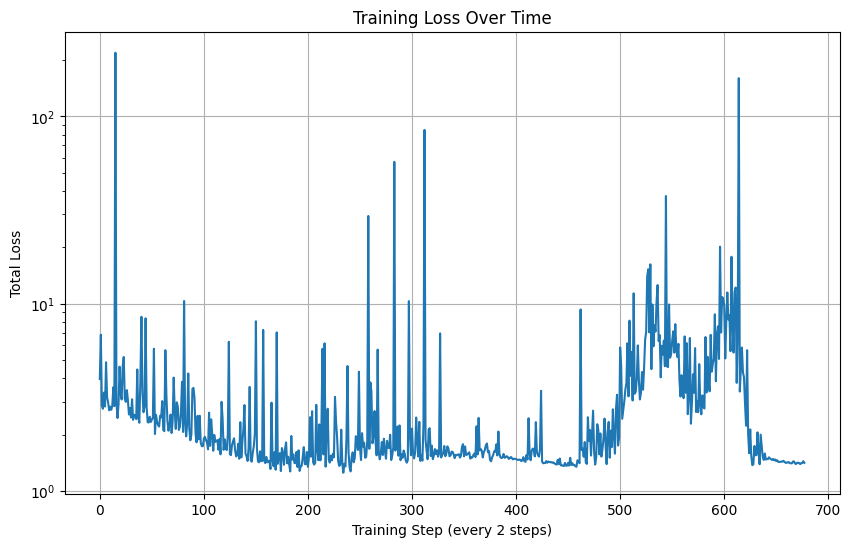

In [112]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.xlabel('Training Step (every 2 steps)')
plt.ylabel('Total Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.yscale('log')
plt.show()